# Customer Segmentation using KMeans Clustering

## Project Overview

Retail businesses generate large volumes of transactional customer data, but identifying meaningful customer groups from that data is often challenging.

This project applies KMeans clustering on customer behavioural and transactional features to segment customers into actionable business groups such as High-Value, Growth, and At-Risk customers.

**Workflow:**
1. Data Loading
2. Data Cleaning & EDA
3. Feature Engineering
4. Preprocessing & Scaling
5. KMeans Clustering (PCA-based)
6. Cluster Profiling & Business Insights

## 1. Data Loading

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

url1 = "https://raw.githubusercontent.com/GodOfWRaTH4848/Customer-segmentation-using-clustering/refs/heads/main/data/transactions.csv"
url2 = "https://raw.githubusercontent.com/GodOfWRaTH4848/Customer-segmentation-using-clustering/refs/heads/main/data/customers.csv"

transactions = pd.read_csv(url1)
customers = pd.read_csv(url2)

print("Transactions shape:", transactions.shape)
print("Customers shape:", customers.shape)

Transactions shape: (32295, 10)
Customers shape: (5000, 12)


## 2. Exploratory Data Analysis

### Data Structure & Quality Check

In [128]:
# Summary of both datasets
def summary(df, name):
    print(f"\n--- {name} ---")
    s = pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.count(),
        'nulls': df.isnull().sum(),
        'null_%': (df.isnull().sum() / len(df) * 100).round(2),
        'distinct': df.nunique()
    })
    print(s)

summary(transactions, "transactions")
summary(customers, "customers")


--- transactions ---
                    dtype  non_null  nulls  null_%  distinct
transaction_id     object     32295      0    0.00     32295
customer_id        object     32295      0    0.00      4618
product_name       object     31617    678    2.10        75
product_category   object     31609    686    2.12        15
quantity          float64     31651    644    1.99        45
price             float64     31673    622    1.93     27603
transaction_date   object     32295      0    0.00      1761
store_location     object     31651    644    1.99        11
payment_method     object     31635    660    2.04         7
discount_applied  float64     31684    611    1.89         7

--- customers ---
                     dtype  non_null  nulls  null_%  distinct
customer_id         object      5000      0    0.00      5000
full_name           object      4894    106    2.12      4720
age                float64      4814    186    3.72        57
gender              object      4888    

### Missing Values

In [129]:
# Check data retained after dropping nulls
for df, name in [(customers, 'customers'), (transactions, 'transactions')]:
    retained = df.dropna().shape[0]
    pct = round(retained * 100 / df.shape[0], 2)
    print(f"{name}: {retained}/{df.shape[0]} rows retained after dropping nulls ({pct}%)")

customers.dropna(inplace=True)
transactions.dropna(inplace=True)

customers: 3864/5000 rows retained after dropping nulls (77.28%)
transactions: 28009/32295 rows retained after dropping nulls (86.73%)


### Merging Datasets

In [130]:
# Drop PII columns not needed for analysis
customers.drop(['email', 'phone', 'full_name'], axis=1, inplace=True)

# Inner join - only customers with transactions
merged_df = pd.merge(transactions, customers, on='customer_id', how='inner')

# Fix dtypes
merged_df['quantity'] = merged_df['quantity'].astype('int64')
merged_df['age'] = merged_df['age'].astype('int64')
merged_df['registration_date'] = pd.to_datetime(merged_df['registration_date'])
merged_df['transaction_date'] = pd.to_datetime(merged_df['transaction_date'])

print("Merged shape:", merged_df.shape)
print("Null values:", merged_df.isnull().sum().sum())
merged_df.head()

Merged shape: (21677, 18)
Null values: 0


,transaction_id,customer_id,product_name,product_category,quantity,price,transaction_date,store_location,payment_method,discount_applied,age,gender,street_address,city,state,zip_code,registration_date,preferred_channel
0,53e3d9f5-6231-46de-aa39-e5f8eaae2eee,727839b2-f084-4e94-94d8-ae59cc8e4b84,Ring Doorbell,Smart Home Devices,1,140.07,2020-12-06,"Houston, TX",Credit Card,20.0,33,Male,62658 Samuel Courts Apt. 819,Miami,Florida,51882.0,2020-06-01,in-store
1,ae6e6edf-f2fe-45c8-989c-c01e77eade0c,c4ac244c-989e-46fb-b243-91dd1d5cf739,Oculus Quest,Gaming Consoles,1,339.57,2021-04-26,Online,Gift Card,0.0,18,Male,775 Smith Pass,San Antonio,Texas,80317.0,2021-02-09,online
2,3725a285-2a2b-4a80-b317-7c8041cd9b8b,7b1b9980-9d65-40fc-8ad6-6afaae4699e4,External Hard Drive,Computer Accessories,1,91.56,2023-03-16,Online,Credit Card,25.0,40,Male,546 Miller Circle Suite 906,Pittsburgh,Pennsylvania,14741.0,2020-12-31,online
3,de1b05a5-68c7-4b00-a068-e8c2f13f0dab,8595dcfa-2bfc-46f4-a15a-042af85b78cd,MacBook Pro,Laptops,1,985.15,2022-08-30,"Atlanta, GA",Credit Card,0.0,26,Male,8179 Mason River Suite 454,San Jose,California,68597.0,2022-04-11,in-store
4,c0250388-c402-4a2a-9b6c-4a65e2ab7ca3,70e505f7-c48f-4cbc-9198-81990224d5b4,Range Hood,Kitchen Appliances,1,215.94,2021-12-09,"Boston, MA",Credit Card,0.0,31,Non-binary,52941 Linda Haven Suite 892,Scottsdale,Arizona,82397.0,2021-05-07,both


### Univariate & Bivariate Analysis

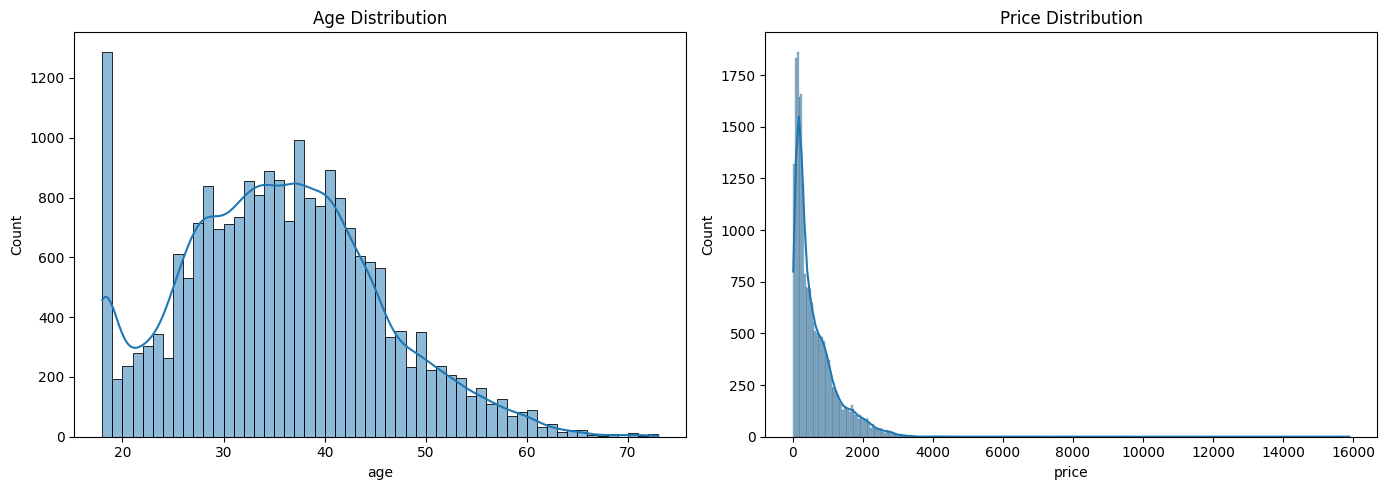

In [131]:
# Age and price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(merged_df['age'], kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(merged_df['price'], kde=True, ax=axes[1])
axes[1].set_title('Price Distribution')

plt.tight_layout()
plt.show()

**Inference**: Age follows a near-normal distribution. Price is right-skewed, suggesting a few high-value transactions.

In [132]:
#Price by product category
prod_cat = transactions.groupby('product_category').agg({'quantity': 'sum', 'price': 'mean'}).reset_index()
print(prod_cat.sort_values('price', ascending=False))

            product_category  quantity        price
13                       TVs    1657.0  1721.932635
9                    Laptops    2386.0  1542.441824
4          Desktop Computers     801.0  1305.610505
5                  Furniture    5075.0  1128.859903
12               Smartphones    5553.0   818.991612
8         Kitchen Appliances    4784.0   566.263207
14                   Tablets     755.0   510.486171
6            Gaming Consoles    2458.0   400.874156
0            Audio Equipment    2309.0   283.613179
3                   Cookware     875.0   232.423887
11        Smart Home Devices    5639.0   170.878512
1                    Bedding     794.0   167.826558
7                 Home Decor    4875.0   164.290914
10  Small Kitchen Appliances    1604.0   115.373187
2       Computer Accessories     803.0    85.246327


In [133]:
# Payment method distribution
trans_per_method = (transactions['payment_method'].value_counts()
                    .rename_axis('payment_method').reset_index(name='count'))
trans_per_method['pct'] = (trans_per_method['count'] / trans_per_method['count'].sum() * 100).round(1)
print(trans_per_method)

  payment_method  count   pct
0    Credit Card   9650  34.5
1     Debit Card   7081  25.3
2         PayPal   4223  15.1
3      Apple Pay   2810  10.0
4     Google Pay   1425   5.1
5      Gift Card   1421   5.1
6           Cash   1399   5.0


**Observation**: Payment methods are spread reasonably. Cards dominate. These will be grouped for ML.

## 3. Feature Engineering

In [134]:
analysis_df = merged_df.copy()

# --- Revenue ---
# sold_price accounts for discount applied at checkout
analysis_df['sold_price'] = analysis_df['price'] * (1 - analysis_df['discount_applied'] / 100)
analysis_df['revenue'] = analysis_df['sold_price'] * analysis_df['quantity']

# --- Log-transform revenue (reduces skew) ---
analysis_df['log_rev'] = np.log1p(analysis_df['revenue'])

print("Revenue nulls:", analysis_df['revenue'].isnull().sum())

Revenue nulls: 0


**Impact**: `revenue` captures actual customer spend (post-discount × quantity). Log transform normalises the heavy right skew.

In [135]:
# --- Age groups ---
age_bins = [18, 26, 36, 46, 56, np.inf]
age_labels = ['18-25', '26-35', '36-45', '46-55', '55+']
analysis_df['age_group'] = pd.cut(analysis_df['age'], bins=age_bins, labels=age_labels, right=False)

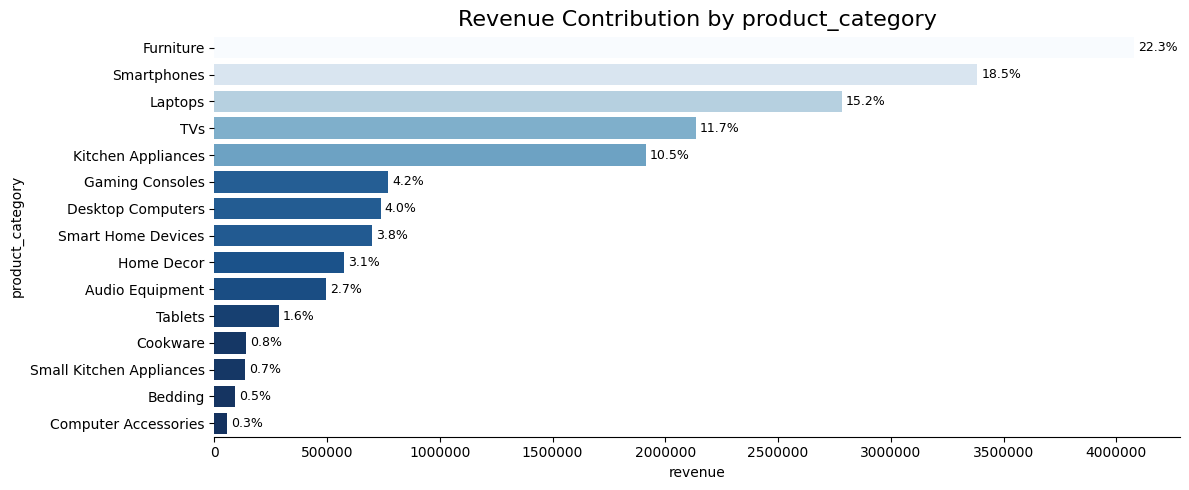

In [136]:
# Helper: revenue contribution by category
def plot_revenue_contribution_by_category(category):
    plt.figure(figsize=(12, 5))
    plt.title(f"Revenue Contribution by {category}", fontsize=16)
    curr_df = (analysis_df.groupby(category, observed=True)['revenue']
               .sum().reset_index().sort_values(by='revenue', ascending=False))
    total = curr_df['revenue'].sum()
    curr_df['pct'] = curr_df['revenue'] / total * 100
    ax = sns.barplot(curr_df, y=category, x='revenue', hue='revenue', orient='h', palette='Blues_r', legend=False)
    for i, p in enumerate(curr_df['pct']):
        ax.text(curr_df['revenue'].iloc[i] + total * 0.001, i, f'{p:.1f}%', va='center', fontsize=9)
    plt.ticklabel_format(style='plain', axis='x')
    sns.despine(top=True, left=True)
    plt.tight_layout()
    plt.show()

plot_revenue_contribution_by_category('product_category')

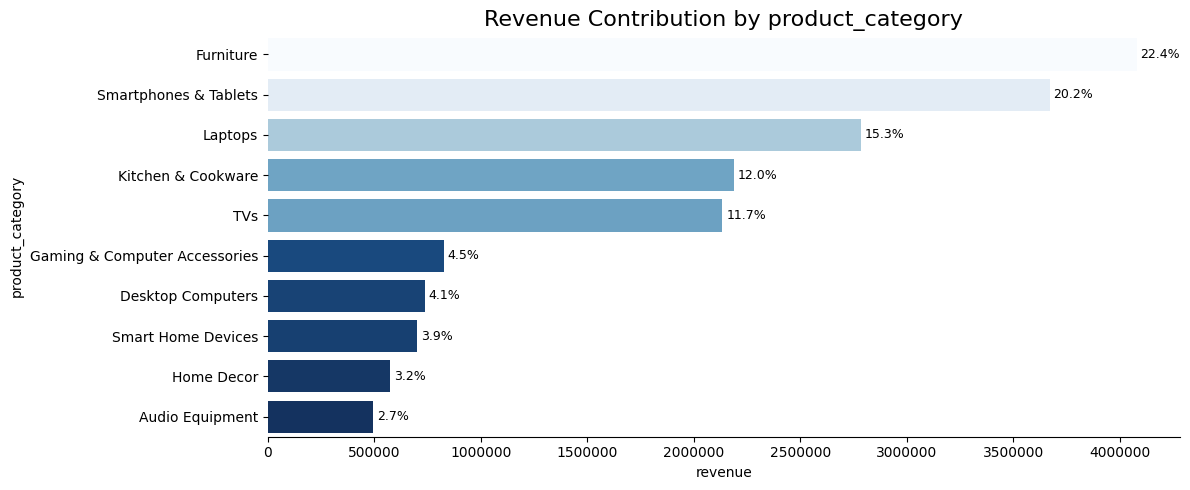

In [137]:
# Remove Bedding (contributes only 0.5%)
analysis_df = analysis_df[analysis_df['product_category'] != 'Bedding']

# Combine similar product categories
analysis_df['product_category'] = analysis_df['product_category'].replace({
    'Gaming Consoles': 'Gaming & Computer Accessories',
    'Computer Accessories': 'Gaming & Computer Accessories',
    'Small Kitchen Appliances': 'Kitchen & Cookware',
    'Kitchen Appliances': 'Kitchen & Cookware',
    'Cookware': 'Kitchen & Cookware',
    'Smartphones': 'Smartphones & Tablets',
    'Tablets': 'Smartphones & Tablets'
})

plot_revenue_contribution_by_category('product_category')

**Impact**: Grouped categories now each contribute >1% of revenue, making them more meaningful for analysis.

In [138]:
# --- Group store locations: online vs physical ---
analysis_df['store_location'] = analysis_df['store_location'].apply(
    lambda x: 'online' if 'online' in str(x).lower() else 'physical store'
)

# --- Group payment methods into 3 buckets ---
payment_mapping = {
    'Credit Card': 'Cards', 'Debit Card': 'Cards',
    'PayPal': 'Merchant Payments', 'Apple Pay': 'Merchant Payments', 'Google Pay': 'Merchant Payments',
    'Gift Card': 'Gift/Cash/Other', 'Cash': 'Gift/Cash/Other'
}
analysis_df['payment_group'] = analysis_df['payment_method'].map(payment_mapping)
analysis_df.drop(columns='payment_method', inplace=True)

print("Store locations:", analysis_df['store_location'].value_counts().to_dict())
print("Payment groups:", analysis_df['payment_group'].value_counts().to_dict())

Store locations: {'online': 10955, 'physical store': 10288}
Payment groups: {'Cards': 12606, 'Merchant Payments': 6477, 'Gift/Cash/Other': 2160}


**Impact**: Grouping reduces sparsity before one-hot encoding and makes features more interpretable for clustering.

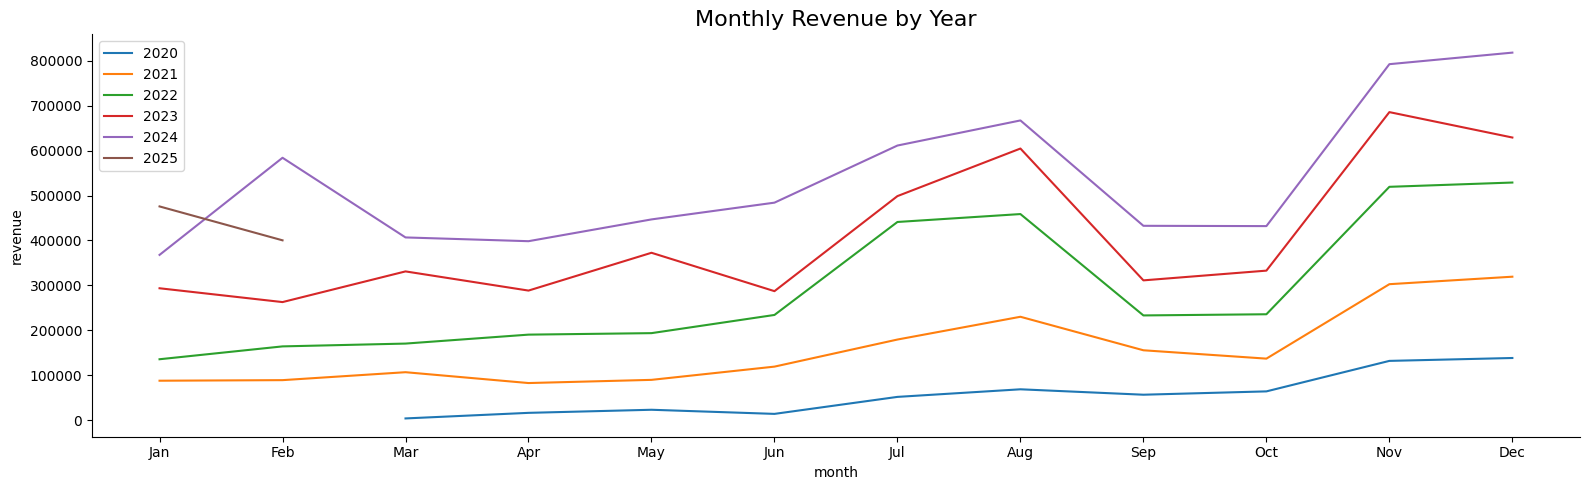

In [139]:
# --- Revenue trend over time ---
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter

analysis_df['year'] = analysis_df['transaction_date'].dt.year
analysis_df['month'] = analysis_df['transaction_date'].dt.month

yearly_revenue = analysis_df.groupby(['year', 'month'])['revenue'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.title('Monthly Revenue by Year', fontsize=16)
for year in sorted(yearly_revenue['year'].unique()):
    df_yr = yearly_revenue[yearly_revenue['year'] == year]
    sns.lineplot(data=df_yr, x='month', y='revenue', label=year)
plt.xticks(ticks=range(1, 13), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

**Observation**: Revenue peaks consistently in Nov-Dec (holiday season) and again mid-year (Jul-Aug), suggesting seasonal campaign opportunities.

## 4. Building ML-Ready DataFrame

### Customer-level Behavioural Features (Recency, Frequency, Monetary)

In [140]:
# Snapshot date = day after last transaction
snapshot_date = analysis_df['transaction_date'].max() + pd.Timedelta(days=1)

# Recency: days since last purchase (lower = more recent)
# Frequency: number of transactions
# Monetary: total revenue (log-transformed)
rfm = analysis_df.groupby('customer_id').agg(
    recency=('transaction_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('transaction_id', 'count'),
    monetary=('revenue', 'sum')
).reset_index()

rfm['monetary_log'] = np.log1p(rfm['monetary'])
rfm.drop(columns='monetary', inplace=True)

print(rfm.describe())
rfm.head()

           recency    frequency  monetary_log
count  3513.000000  3513.000000   3513.000000
mean    152.419584     6.046968      8.045297
std     160.534769     4.065216      1.147861
min       1.000000     1.000000      3.114626
25%      55.000000     3.000000      7.443811
50%      96.000000     5.000000      8.255121
75%     196.000000     9.000000      8.849586
max    1203.000000    29.000000     11.716786


,customer_id,recency,frequency,monetary_log
0,00012aa8-e99c-4e30-b3f6-1f7e36adc517,36,5,7.914055
1,00107f62-0530-48ec-a56a-49d90944eafe,75,1,5.093689
2,00a6835b-c50a-49a9-a1b5-19d74d3e1863,26,7,8.176431
3,00a90d43-e62f-4e16-9a17-948d25c9684b,60,6,8.544706
4,00ca767b-0217-46ba-b482-021916fa1be0,34,2,5.400829


Recency, Frequency and Monetary value are the three widely used dimensions of customer behaviour for segmentation.

In [141]:
# since_signup_days: customer tenure (how long they've been registered)
latest_tx = analysis_df['transaction_date'].max()
signup_info = (analysis_df[['customer_id', 'registration_date']]
               .drop_duplicates('customer_id')
               .copy())
signup_info['registration_date'] = pd.to_datetime(signup_info['registration_date'])
signup_info['since_signup_days'] = (latest_tx - signup_info['registration_date']).dt.days

# Verify no negatives
print("Negative signup days:", (signup_info['since_signup_days'] < 0).sum())

Negative signup days: 0


In [142]:
# Customer-level behavioural aggregations (most frequent store, payment, age group)
customer_behavior = analysis_df.groupby('customer_id').agg(
    store_location=('store_location', lambda x: x.mode().iloc[0]),
    payment_group=('payment_group', lambda x: x.mode().iloc[0]),
    age_group=('age_group', lambda x: x.mode().iloc[0])
).reset_index()

# Merge signup days
customer_behavior = customer_behavior.merge(
    signup_info[['customer_id', 'since_signup_days']], on='customer_id', how='left'
)

customer_behavior.head()

,customer_id,store_location,payment_group,age_group,since_signup_days
0,00012aa8-e99c-4e30-b3f6-1f7e36adc517,online,Merchant Payments,26-35,751
1,00107f62-0530-48ec-a56a-49d90944eafe,physical store,Cards,36-45,251
2,00a6835b-c50a-49a9-a1b5-19d74d3e1863,online,Cards,18-25,1511
3,00a90d43-e62f-4e16-9a17-948d25c9684b,physical store,Cards,36-45,535
4,00ca767b-0217-46ba-b482-021916fa1be0,online,Cards,18-25,339


In [143]:
# Final dataframe: RFM + behavioural features
final_df = rfm.merge(customer_behavior, on='customer_id', how='left')

# One-hot encode categorical features
categorical_cols = ['store_location', 'payment_group', 'age_group']
final_df_encoded = pd.get_dummies(final_df, columns=categorical_cols, drop_first=True)
final_df_encoded = final_df_encoded.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)

# Verify: 1 row per customer
assert final_df_encoded['customer_id'].nunique() == final_df_encoded.shape[0], "Duplicate customers found!"
print("Shape:", final_df_encoded.shape)
print("Columns:", list(final_df_encoded.columns))
final_df_encoded.head()

Shape: (3513, 12)
Columns: ['customer_id', 'recency', 'frequency', 'monetary_log', 'since_signup_days', 'store_location_physical store', 'payment_group_Gift/Cash/Other', 'payment_group_Merchant Payments', 'age_group_26-35', 'age_group_36-45', 'age_group_46-55', 'age_group_55+']


,customer_id,recency,frequency,monetary_log,since_signup_days,store_location_physical store,payment_group_Gift/Cash/Other,payment_group_Merchant Payments,age_group_26-35,age_group_36-45,age_group_46-55,age_group_55+
0,00012aa8-e99c-4e30-b3f6-1f7e36adc517,36,5,7.914055,751,0,0,1,1,0,0,0
1,00107f62-0530-48ec-a56a-49d90944eafe,75,1,5.093689,251,1,0,0,0,1,0,0
2,00a6835b-c50a-49a9-a1b5-19d74d3e1863,26,7,8.176431,1511,0,0,0,0,0,0,0
3,00a90d43-e62f-4e16-9a17-948d25c9684b,60,6,8.544706,535,1,0,0,0,1,0,0
4,00ca767b-0217-46ba-b482-021916fa1be0,34,2,5.400829,339,0,0,0,0,0,0,0


## 5. Preprocessing & Scaling

In [144]:
ml_df = final_df_encoded.copy()

# Scale numeric features only (KMeans is distance-based so scale matters)
numeric_cols = ['recency', 'frequency', 'monetary_log', 'since_signup_days']
scaler = StandardScaler()
ml_df[numeric_cols] = scaler.fit_transform(ml_df[numeric_cols])

print("Scaling complete. Sample:")
ml_df[numeric_cols].describe().round(2)

Scaling complete. Sample:


,recency,frequency,monetary_log,since_signup_days
count,3513.00,3513.00,3513.00,3513.00
mean,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-0.94,-1.24,-4.30,-1.99
25%,-0.61,-0.75,-0.52,-0.85
50%,-0.35,-0.26,0.18,0.03
75%,0.27,0.73,0.70,0.85
max,6.55,5.65,3.20,1.71


KMeans uses Euclidean distance. Without scaling, `since_signup_days` (range: 0–1800) would dominate over `frequency` (range: 1–50).

## 6. PCA – Dimensionality Reduction

KMeans on raw features showed heavy correlation between RFM variables (expected — high frequency customers tend to have high monetary value). PCA removes this multicollinearity by projecting into uncorrelated components.

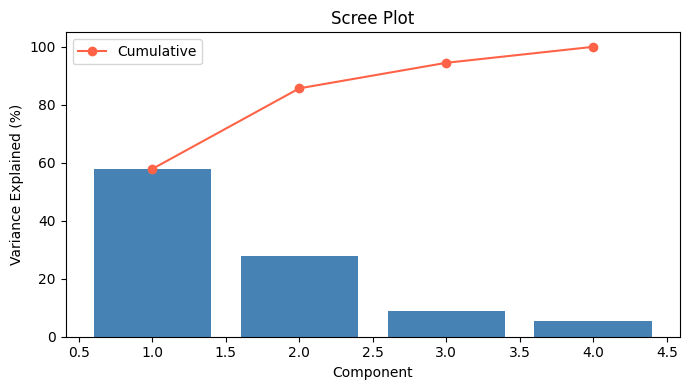

Cumulative variance explained: [0.579 0.857 0.945 1.   ]


In [145]:
# PCA on the 4 numeric features only
numeric_df = ml_df[['recency', 'frequency', 'monetary_log', 'since_signup_days']]

# Scree plot to decide number of components
pca_full = PCA()
pca_full.fit(numeric_df)
explained = pca_full.explained_variance_ratio_

plt.figure(figsize=(7, 4))
plt.bar(range(1, len(explained) + 1), explained * 100, color='steelblue')
plt.plot(range(1, len(explained) + 1), np.cumsum(explained) * 100, marker='o', color='tomato', label='Cumulative')
plt.xlabel('Component')
plt.ylabel('Variance Explained (%)')
plt.title('Scree Plot')
plt.legend()
plt.tight_layout()
plt.show()

print("Cumulative variance explained:", np.cumsum(explained).round(3))

PCA and clustering were intentionally applied only to continuous behavioural variables (RFM + tenure). Categorical variables were retained separately for post-cluster interpretation and profiling.

**Observation**: 3 principal components retained the vast majority of variance while reducing redundancy between correlated behavioural variables.

In [146]:
# Apply PCA with 3 components
pca = PCA(n_components=3)
pca_data = pca.fit_transform(numeric_df)

pca_final = pd.DataFrame(pca_data, columns=['PC1', 'PC2', 'PC3'], index=ml_df.index)

# PCA component loadings — what does each component represent?
pd.DataFrame(pca.components_, columns=numeric_df.columns, index=['PC1', 'PC2', 'PC3']).round(3)

,recency,frequency,monetary_log,since_signup_days
PC1,-0.039,0.603,0.578,0.549
PC2,0.927,-0.139,-0.108,0.331
PC3,0.288,-0.115,0.724,-0.616


## 7. KMeans Clustering

### Choosing k — Elbow Method + Silhouette Score

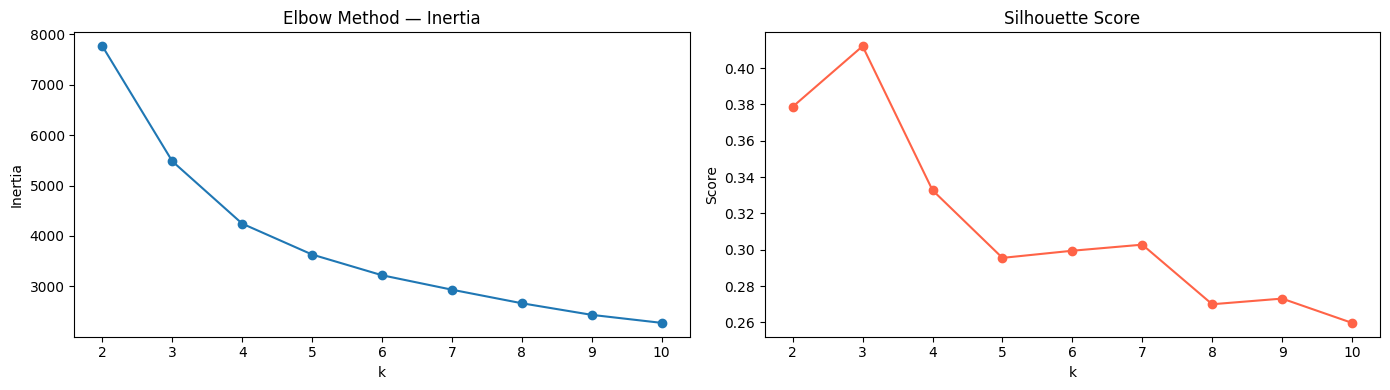

k=2, Silhouette Score = 0.3787
k=3, Silhouette Score = 0.4120
k=4, Silhouette Score = 0.3327
k=5, Silhouette Score = 0.2955
k=6, Silhouette Score = 0.2994
k=7, Silhouette Score = 0.3028
k=8, Silhouette Score = 0.2700
k=9, Silhouette Score = 0.2731
k=10, Silhouette Score = 0.2597


In [147]:
K = range(2, 11)
inertias, sil_scores = [], []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pca_final)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(pca_final, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K, inertias, marker='o')
axes[0].set_title('Elbow Method — Inertia')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(K, sil_scores, marker='o', color='tomato')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

for k, sil in zip(K, sil_scores):
    print(f"k={k}, Silhouette Score = {sil:.4f}")

**Inference**: The silhouette score peaks at **k=3**, and the elbow also starts flattening around k=3–4. We select **k=3** as it gives the best separation and produces three interpretable business segments.

### Fitting Final Model — k=3

In [148]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_final['cluster'] = kmeans.fit_predict(pca_final)

# Attach cluster labels back to the unscaled data for interpretation
df_results = final_df_encoded.copy()
df_results['cluster'] = pca_final['cluster'].values

print("Cluster distribution:")
print(df_results['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0     410
1    1606
2    1497
Name: count, dtype: int64


## 8. Cluster Profiling

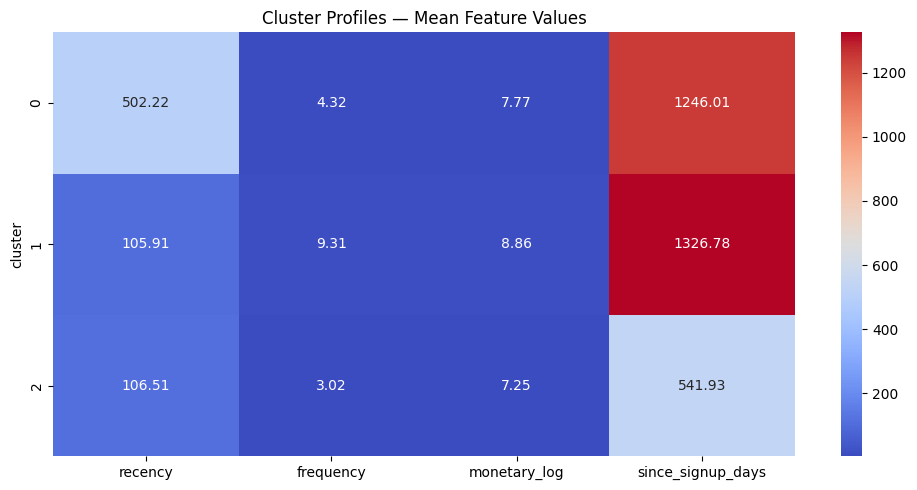

         recency  frequency  monetary_log  since_signup_days
cluster                                                     
0         502.22       4.32          7.77            1246.01
1         105.91       9.31          8.86            1326.78
2         106.51       3.02          7.25             541.93


In [149]:
# Profile using unscaled RFM values
cluster_profiles = df_results.groupby('cluster')[['recency', 'frequency', 'monetary_log', 'since_signup_days']].mean()

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Cluster Profiles — Mean Feature Values')
plt.tight_layout()
plt.show()

print(cluster_profiles.round(2))

In [150]:
cluster_mapping = {0: 'At-Risk', 1: 'High-Value', 2: 'Growth'}

df_results['cluster_label'] = df_results['cluster'].map(cluster_mapping)
print(df_results['cluster_label'].value_counts())

cluster_label
High-Value    1606
Growth        1497
At-Risk        410
Name: count, dtype: int64


## 9. Cluster Visualisations & Business Insights

### Violin Plot — RFM Behaviour by Cluster

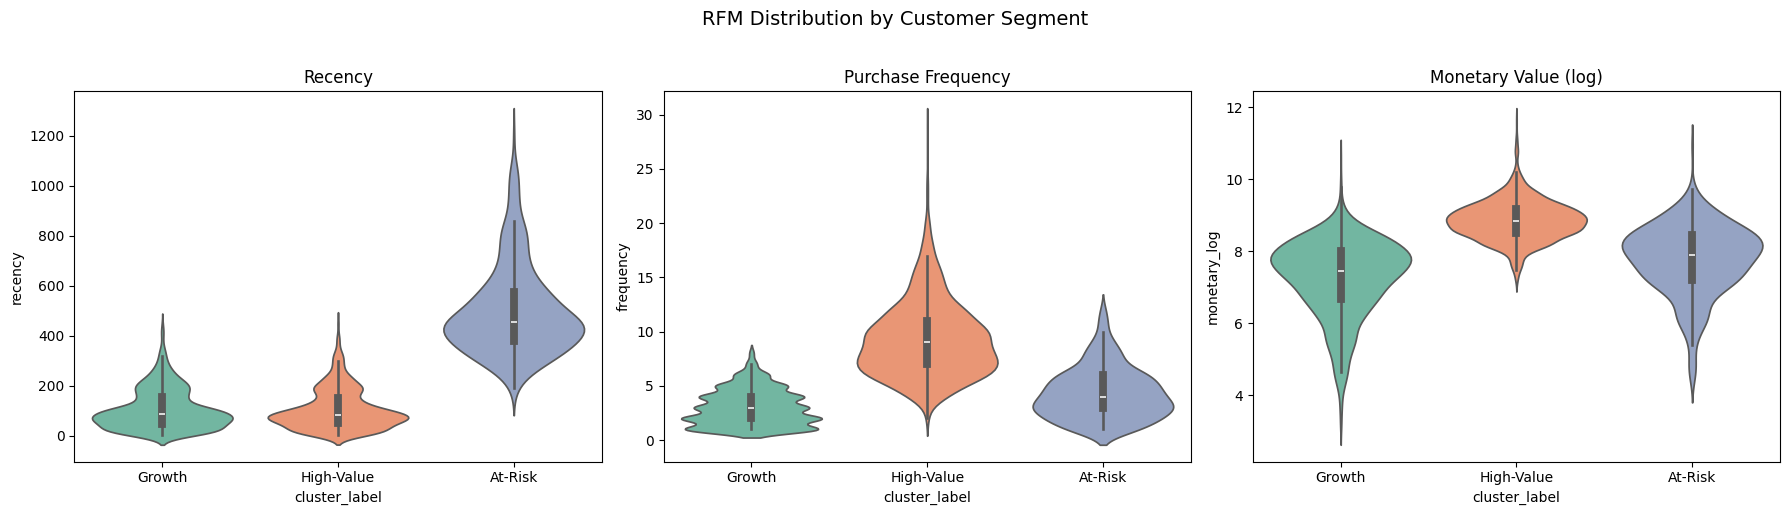

In [151]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(axes,
                           ['recency', 'frequency', 'monetary_log'],
                           ['Recency', 'Purchase Frequency', 'Monetary Value (log)']):
    sns.violinplot(data=df_results, x='cluster_label', y=col,
                   hue='cluster_label', palette='Set2', legend=False, ax=ax)
    ax.set_title(title)

plt.suptitle('RFM Distribution by Customer Segment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Monetary value shows less separation between segments compared to recency and frequency, suggesting spend per transaction is relatively consistent across customer types. The key differentiators in this dataset are recency and frequency.

**Inference**: The violin plots confirm clear behavioural separation. High-Value customers show high frequency and monetary value with low recency. At-Risk customers have high recency (not bought recently) and low engagement.

### Scatter Plot — Customer Lifetime vs Frequency

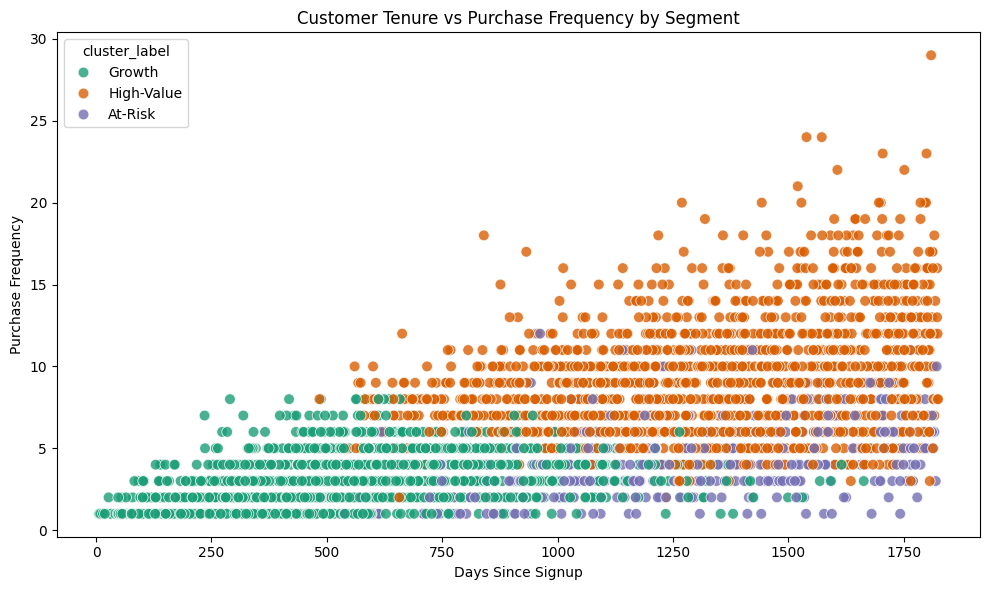

In [152]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_results, x='since_signup_days', y='frequency',
                hue='cluster_label', palette='Dark2', s=60, alpha=0.8)
plt.title('Customer Tenure vs Purchase Frequency by Segment')
plt.xlabel('Days Since Signup')
plt.ylabel('Purchase Frequency')
plt.tight_layout()
plt.show()

**Inference**:
- **High-Value** customers have long tenure and consistently high frequency — deeply engaged, long-term users.
- **Growth** customers are newer but increasing in activity — strong candidates for loyalty incentives.
- **At-Risk** customers have been around a long time but rarely purchase — priority targets for reactivation campaigns.

### Age Group Distribution Across Clusters

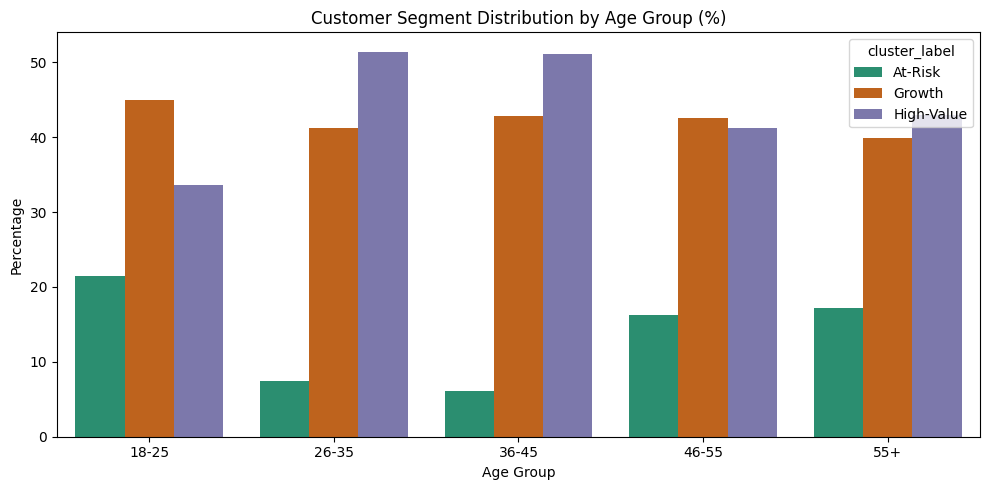

In [153]:
# Decode age_group from one-hot encoded columns
def decode_age_group(row):
    if row.get('age_group_26-35', 0) == 1:
        return '26-35'
    elif row.get('age_group_36-45', 0) == 1:
        return '36-45'
    elif row.get('age_group_46-55', 0) == 1:
        return '46-55'
    elif row.get('age_group_55+', 0) == 1:
        return '55+'
    return '18-25'  # baseline category (dropped by drop_first=True)

df_results['age_group'] = df_results.apply(decode_age_group, axis=1)

age_cluster_pct = (df_results.groupby(['age_group', 'cluster_label'])
                   .size().reset_index(name='count'))
age_cluster_pct['percentage'] = (age_cluster_pct.groupby('age_group')['count']
                                  .transform(lambda x: 100 * x / x.sum()))

plt.figure(figsize=(10, 5))
sns.barplot(data=age_cluster_pct, x='age_group', y='percentage',
            hue='cluster_label', palette='Dark2')
plt.title('Customer Segment Distribution by Age Group (%)')
plt.ylabel('Percentage')
plt.xlabel('Age Group')
plt.tight_layout()
plt.show()

**Inference**: Growth segment dominates across all age groups — a positive signal. At-Risk proportion is lowest in the 26–45 bracket, suggesting mid-career customers are most engaged.

## 10. Summary & Business Recommendations

### Pipeline Summary
1. Loaded and merged two datasets (transactions + customers) with ~87% data retained after null removal.
2. Engineered key features: `revenue`, `log_rev`, `age_group`, `payment_group`, `store_location`, `since_signup_days`, and RFM metrics.
3. Built a customer-level ML dataframe with one row per customer.
4. Applied PCA (3 components, ~100% variance retained) to remove multicollinearity between RFM features.
5. KMeans with k=3 selected based on highest silhouette score.
6. Three distinct segments identified: **High-Value**, **Growth**, **At-Risk**.

### Business Recommendations

| Segment | Characteristic | Action |
|---|---|---|
| **High-Value** | Frequent, high-spend, long-tenure | VIP loyalty rewards, early access, premium support |
| **Growth** | Recent, mid-spend, increasing activity | Targeted upsell, bundle offers, loyalty onboarding |
| **At-Risk** | Long tenure, declining frequency | Reactivation campaigns, win-back discounts, surveys |
